In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage import color
from skimage import measure
from skimage import feature
from skimage import filters
from skimage.segmentation import watershed
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.measure import label
from skimage.segmentation import mark_boundaries
from skimage.color import label2rgb

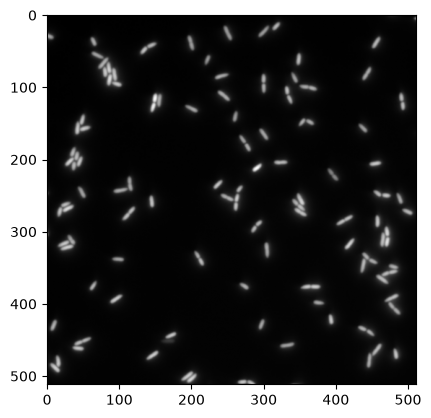

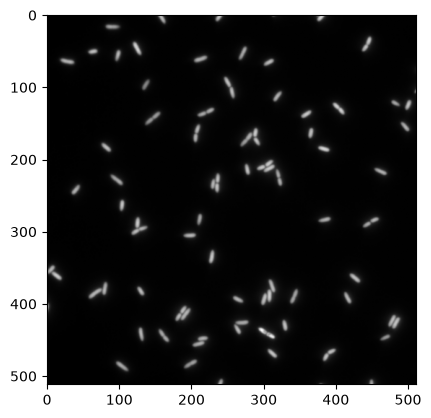

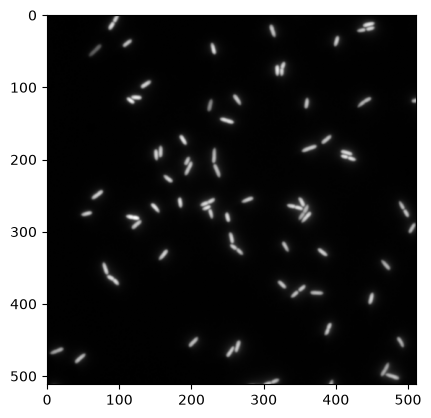

In [28]:
cell1 = io.imread("C:/Users/suzua/Downloads/Cells1.tif")
#fig.ax makes the contrast of the image higher for identification
#don't have to add in brackets cause cell1 is read in fuc
#figure is the number of array and ax is the axis
fig, ax = plt.subplots()
#prints the axis of the individual pixel
ax.imshow(cell1,cmap = 'gray')

cell2 = io.imread ("C:/Users/suzua/Downloads/Cells2.tif")
fig, ax = plt.subplots()
ax.imshow(cell2,cmap = 'gray')

cell3 = io.imread ("C:/Users/suzua/Downloads/Cells3.tif")
fig, ax = plt.subplots()
ax.imshow(cell3,cmap = 'gray')

In [29]:
#finds the numerical value/threshold that separates cell from the bg
optimalthres = filters.threshold_otsu(cell1)
#if the pixel is less than the threshold it turns into "false" and greater into "true" 
binary_cell1 = cell1>optimalthres
print (binary_cell1)

optimalthres = filters.threshold_otsu(cell2)
binary_cell2 = cell2>optimalthres
print (binary_cell2)

optimalthres = filters.threshold_otsu(cell3)
binary_cell3 = cell3>optimalthres
print (binary_cell3)

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


In [30]:
#binarycell1 is false and true array made from the picture
#return_num=true tells us the number of white plots/true and 0 is treated as bg
arraycell1,objnum1 = measure.label(binary_cell1, return_num=True, background=0)
#objnum is the returned value of how many 1s there are thats touching each other
arraycell2,objnum2 = measure.label(binary_cell2, return_num=True, background =0)
arraycell3,objnum3 = measure.label(binary_cell3, return_num=True, background=0)

In [31]:
print(arraycell1,objnum1)
print(arraycell2,objnum2)
print(arraycell3,objnum3)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] 77
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] 68
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] 55


Text(0.5, 1.0, 'Number of Cells: 55')

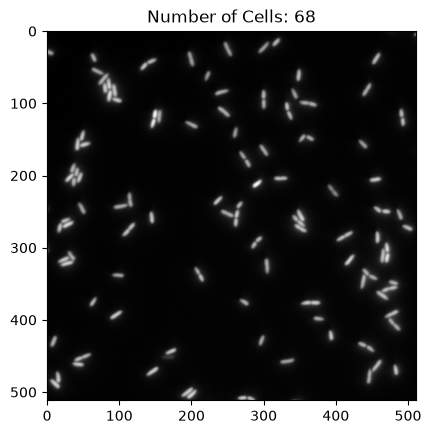

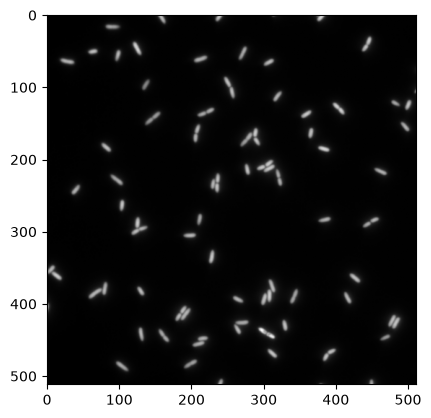

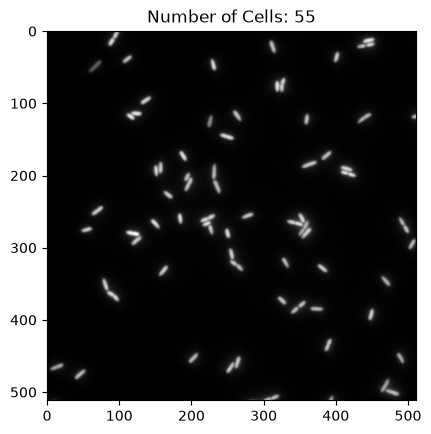

In [62]:
#f string reads the actual property in {}
cell1 = io.imread("C:/Users/suzua/Downloads/Cells1.tif")
fig, ax = plt.subplots()
ax.imshow(cell1,cmap = 'gray')
ax.set_title(f"Number of Cells: {objnum1}")

ax.set_title(f"Number of Cells: {objnum2}")
cell2 = io.imread ("C:/Users/suzua/Downloads/Cells2.tif")
fig, ax = plt.subplots()
ax.imshow(cell2,cmap = 'gray')

cell3 = io.imread ("C:/Users/suzua/Downloads/Cells3.tif")
fig, ax = plt.subplots()
ax.imshow(cell3,cmap = 'gray')
ax.set_title(f"Number of Cells: {objnum3}")

Text(0.5, 1.0, 'Number of Cells: 55')

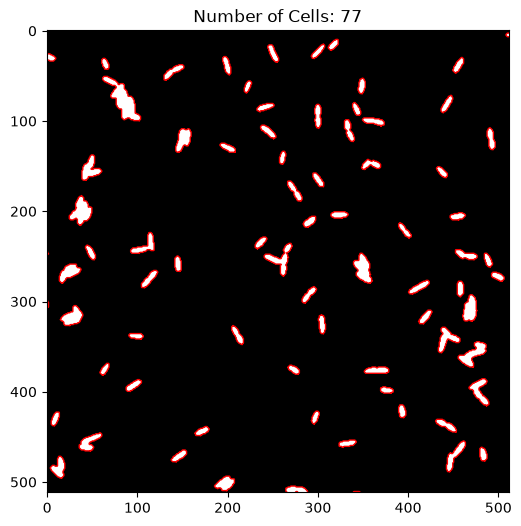

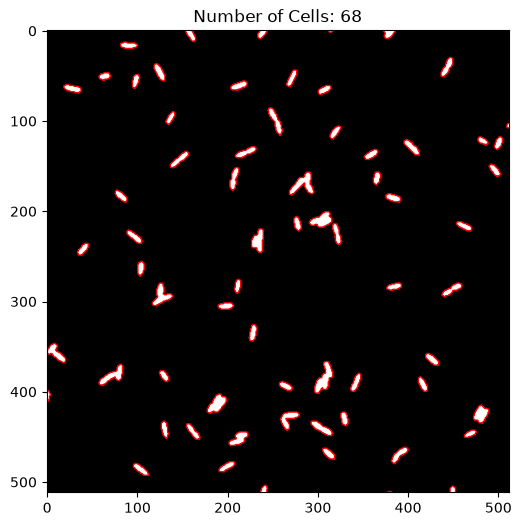

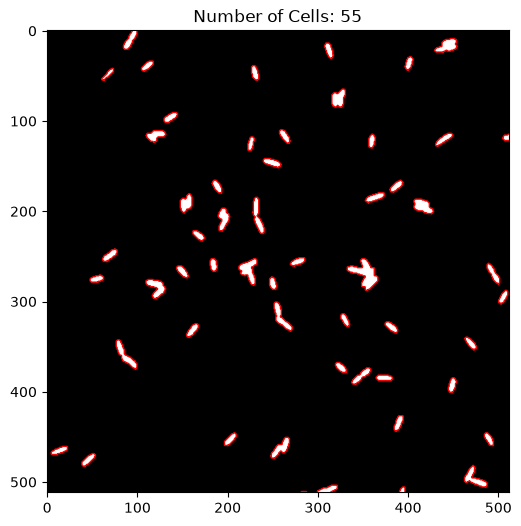

In [63]:
#we've been able to make the code count the cells but its not to accurate
contours = measure.find_contours(binary_cell1)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(binary_cell1, cmap='gray')
#creates a loop and goes through every single cell outline
for contours in contours:
    ax.plot(contours[:, 1], contours[:, 0], color='red', linewidth=1)
ax.set_title(f'Number of Cells: {objnum1}')

#we've been able to make the code count the cells but its not to accurate
contours = measure.find_contours(binary_cell2)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(binary_cell2, cmap='gray')
#creates a loop and goes through every single cell outline
for contours in contours:
    ax.plot(contours[:, 1], contours[:, 0], color='red', linewidth=1)
ax.set_title(f'Number of Cells: {objnum2}')

#we've been able to make the code count the cells but its not to accurate
contours = measure.find_contours(binary_cell3)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(binary_cell3, cmap='gray')
#creates a loop and goes through every single cell outline
for contours in contours:
    ax.plot(contours[:, 1], contours[:, 0], color='red', linewidth=1)
ax.set_title(f'Number of Cells: {objnum3}')

Text(0.5, 1.0, 'Number of Cells: 103')

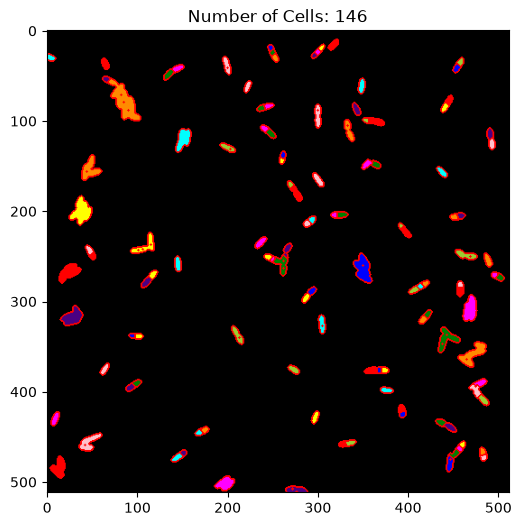

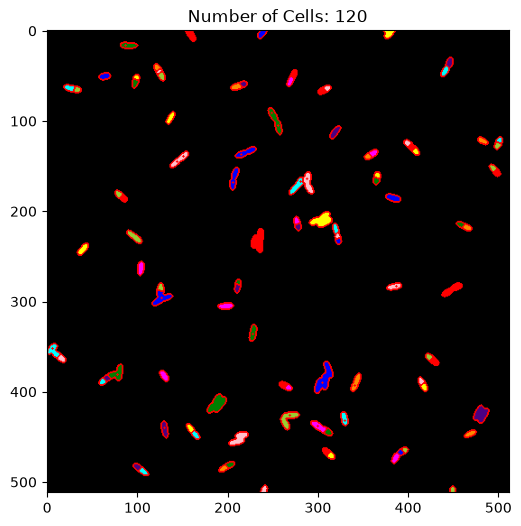

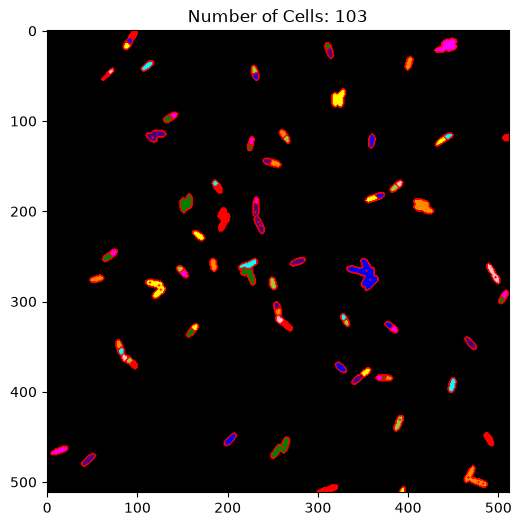

In [79]:
#calculates the dist of the closest 0 to a 1
distance = ndi.distance_transform_edt(binary_cell1)
#the highest distance is found, the min distance tells the code that if peaks are <4 pixels apart js ignore
coords = peak_local_max(distance, min_distance=4, labels=binary_cell1)
#a blank canvas is created
markers_mask = np.zeros(distance.shape, dtype=bool)
#coordinates found by peak_local_max and changes those specific pixels on your blank canvas from False to True
markers_mask[tuple(coords.T)] = True
#scans markers_mask canvas, finds the first pixel marked true and numbers it 1, the second one 2 and so on
marker = label(markers_mask)
watershed1 = watershed(distance, marker, mask=binary_cell1)
watershedcount1=np.max(watershed1)
colored_cells1 = label2rgb(watershed1, bg_label=0)
fig, ax = plt.subplots(figsize=(6, 6))
outlined_image1 = mark_boundaries(colored_cells1,watershed1, color=(1, 0, 0),mode='thick')
ax.imshow(outlined_image1)
ax.set_title(f'Number of Cells: {watershedcount1}')

distance = ndi.distance_transform_edt(binary_cell2)
coords = peak_local_max(distance, min_distance=4, labels=binary_cell2)
markers_mask = np.zeros(distance.shape, dtype=bool)
markers_mask[tuple(coords.T)] = True
marker = label(markers_mask)
watershed2 = watershed(distance, marker, mask=binary_cell2)
watershedcount2=np.max(watershed2)
colored_cells2 = label2rgb(watershed2, bg_label=0)
fig, ax = plt.subplots(figsize=(6, 6))
outlined_image2 = mark_boundaries(colored_cells2,watershed2, color=(1, 0, 0),mode='thick')
ax.imshow(outlined_image2)
ax.set_title(f'Number of Cells: {watershedcount2}')

distance = ndi.distance_transform_edt(binary_cell3)
coords = peak_local_max(distance, min_distance=4, labels=binary_cell3)
markers_mask = np.zeros(distance.shape, dtype=bool)
markers_mask[tuple(coords.T)] = True
marker = label(markers_mask)
watershed3 = watershed(distance, marker, mask=binary_cell3)
watershedcount3=np.max(watershed3)
colored_cells3 = label2rgb(watershed3, bg_label=0)
fig, ax = plt.subplots(figsize=(6, 6))
outlined_image3 = mark_boundaries(colored_cells3,watershed3, color=(1, 0, 0),mode='thick')
ax.imshow(outlined_image3)
ax.set_title(f'Number of Cells: {watershedcount3}')